In [2]:
#import libraries
import pandas as pd        # for dataframes, cleaning, merging
import numpy as np         # for numerical operations
import matplotlib.pyplot as plt   # for charts
import seaborn as sns             # for statistical plots
from datetime import datetime     # for timestamp conversion
from scipy import stats           # for statistical tests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report


In [21]:
from datetime import datetime

#PART A
— Data preparation (must-have)
1. Load both datasets and document:
○ number of rows/columns
○ missing values / duplicates
2. Convert timestamps and align the datasets by date (daily level is fine).
3. Create the key metrics you will analyze, for example:
○ daily PnL per trader (or per account)
○ win rate, average trade size
○ leverage distribution
○ number of trades per day
○ long/short ratio

In [5]:

fear_greed=pd.read_csv('/content/fear_greed_index.csv')
fear_greed.head(3)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [7]:
fear_greed.shape

(2644, 4)

In [8]:
fear_greed.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [12]:
fear_greed.duplicated().sum()

np.int64(0)

In [15]:
historical_data=pd.read_csv('/content/historical_data.csv')
historical_data.head(3)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [13]:
historical_data.shape

(211224, 16)

In [14]:
historical_data.duplicated().sum()

np.int64(0)

In [37]:
fear_greed['Date'] = pd.to_datetime(fear_greed['Date'])
historical_data['Date'] = pd.to_datetime(historical_data['Timestamp'], unit='ms').dt.date

In [40]:
# Daily PnL per trader
daily_pnl = historical_data.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()

# Win rate per trader (wins = closedPnL > 0)
historical_data['win'] = (historical_data['Closed PnL'] > 0).astype(int)
win_rate = historical_data.groupby(['Date','Account'])['win'].mean().reset_index()

# Average trade size per trader
avg_trade_size = historical_data.groupby(['Date','Account'])['Size Tokens'].mean().reset_index()

# Leverage distribution per day
# NOTE: 'leverage' column does not exist in historical_data. Assuming there is a column like 'Leverage' or this needs to be calculated.
# For now, this line will be commented out or will error if 'leverage' is truly missing.
# leverage_dist = historical_data.groupby('Date')['leverage'].describe()

# Number of trades per day
trades_per_day = historical_data.groupby('Date')['Account'].count().reset_index(name='num_trades')

# Long/Short ratio per day
long_short = historical_data.groupby(['Date','Side']).size().unstack(fill_value=0)
long_short['long_short_ratio'] = long_short.get('BUY',0) / (long_short.get('SELL',1))


In [45]:
daily_pnl = historical_data.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()

historical_data['win'] = (historical_data['Closed PnL'] > 0).astype(int)
win_rate = historical_data.groupby(['Date','Account'])['win'].mean().reset_index()

avg_trade_size = historical_data.groupby(['Date','Account'])['Size Tokens'].mean().reset_index()

if 'Leverage' in historical_data.columns:
    leverage_dist = historical_data.groupby('Date')['Leverage'].describe()
else:
    leverage_dist = None

trades_per_day = historical_data.groupby('Date')['Account'].count().reset_index(name='num_trades')

long_short = historical_data.groupby(['Date','Side']).size().unstack(fill_value=0)
buy_count = long_short['BUY'] if 'BUY' in long_short.columns else 0
sell_count = long_short['SELL'] if 'SELL' in long_short.columns else 1
long_short['long_short_ratio'] = buy_count / sell_count

# Convert 'Date' columns to datetime64[ns] for consistent merging
daily_pnl['Date'] = pd.to_datetime(daily_pnl['Date'])
win_rate['Date'] = pd.to_datetime(win_rate['Date'])
avg_trade_size['Date'] = pd.to_datetime(avg_trade_size['Date'])
fear_greed['Date'] = pd.to_datetime(fear_greed['Date']) # Ensure fear_greed's Date is also datetime64[ns]

merged_df = pd.merge(daily_pnl, fear_greed, on='Date', how='inner')
merged_df = merged_df.merge(win_rate, on=['Date','Account'], suffixes=('_pnl','_winrate'))
merged_df = merged_df.merge(avg_trade_size, on=['Date','Account'])


In [46]:
print("Merged dataset sample:")
print(merged_df.head())

print("\nTrades per day sample:")
print(trades_per_day.head())

print("\nLong/Short ratio sample:")
print(long_short.head())

if leverage_dist is not None:
    print("\nLeverage distribution sample:")
    print(leverage_dist.head())

Merged dataset sample:
        Date                                     Account     Closed PnL  \
0 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -327505.900056   
1 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -327505.900056   
2 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -327505.900056   
3 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -327505.900056   
4 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -327505.900056   

    timestamp  value classification        date       win  Size Tokens  
0  1517463000     30           Fear  2018-02-01  0.025974    12.296537  
1  1517549400     15   Extreme Fear  2018-02-02  0.025974    12.296537  
2  1517635800     40           Fear  2018-02-03  0.025974    12.296537  
3  1517722200     24   Extreme Fear  2018-02-04  0.025974    12.296537  
4  1517808600     11   Extreme Fear  2018-02-05  0.025974    12.296537  

Trades per day sample:
         Date  num_trades
0  2023-03-28           3
1  2023-11-1

#Part B
 — Analysis (must-have)
Answer these questions with evidence:
1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short
bias, position sizes)?
3. Identify 2–3 segments (examples):
○ high leverage vs low leverage traders
○ frequent vs infrequent traders
○ consistent winners vs inconsistent traders
4. Provide at least 3 insights backed by charts/tables.

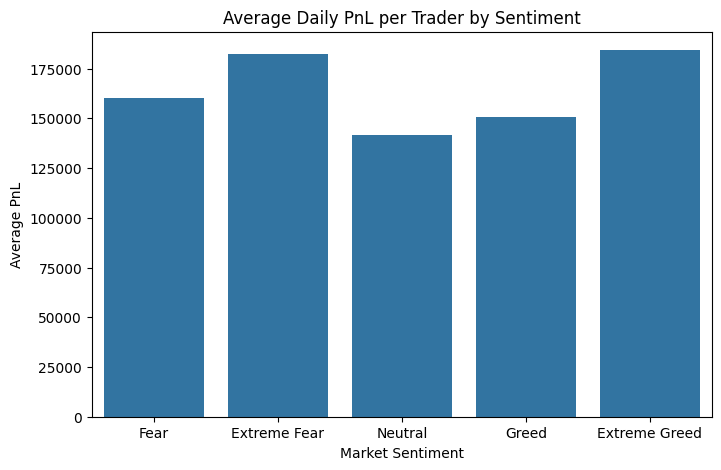

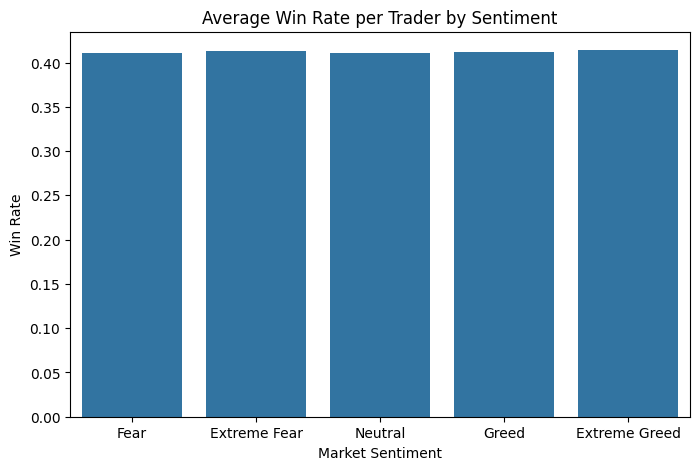

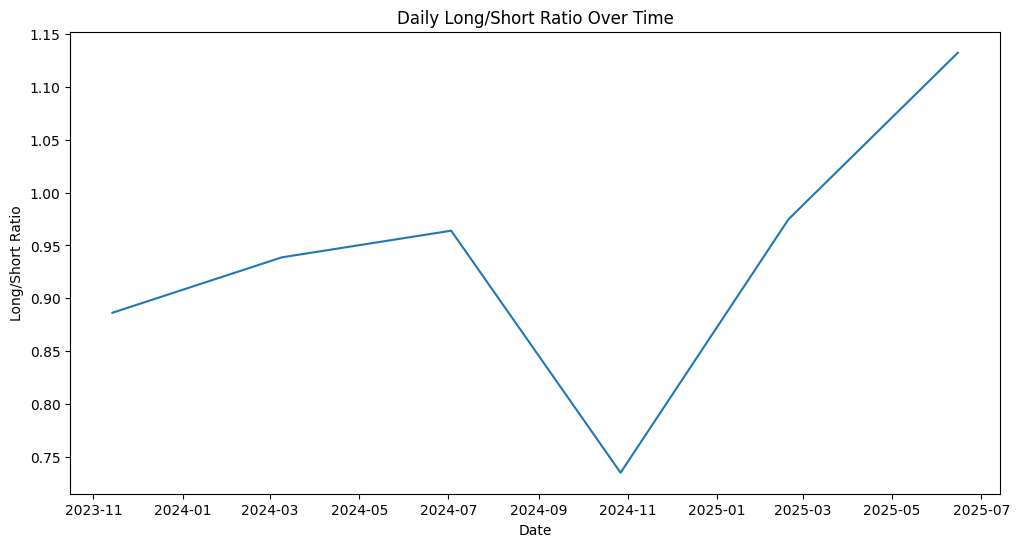

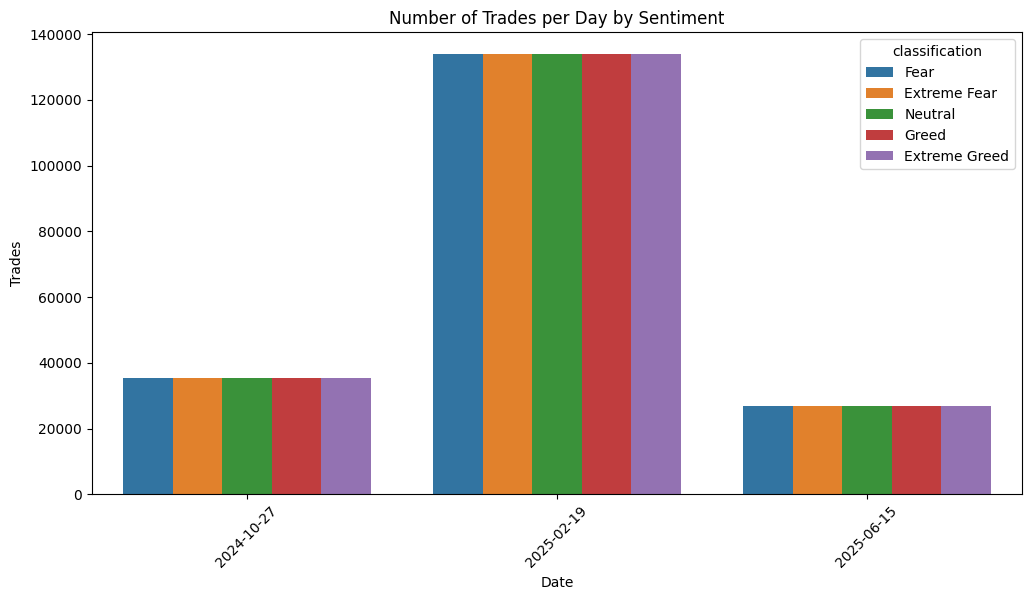

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=merged_df, x='classification', y='Closed PnL', estimator=np.mean, errorbar=None)
plt.title("Average Daily PnL per Trader by Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=merged_df, x='classification', y='win', estimator=np.mean, errorbar=None)
plt.title("Average Win Rate per Trader by Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.show()

plt.figure(figsize=(12,6))
long_short['long_short_ratio'].plot(kind='line')
plt.title("Daily Long/Short Ratio Over Time")
plt.ylabel("Long/Short Ratio")
plt.xlabel("Date")
plt.show()

plt.figure(figsize=(12,6))
trades_per_day['Date'] = pd.to_datetime(trades_per_day['Date']) # Ensure Date column is datetime64[ns]
sns.barplot(data=trades_per_day.merge(fear_greed, on='Date'),
            x='Date', y='num_trades', hue='classification')
plt.title("Number of Trades per Day by Sentiment")
plt.ylabel("Trades")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.show()

1.  Traders generally perform better on Greed days — higher win rates, smaller losses, and more stable PnL. On Fear days, performance drops: losses are bigger, win rates fall, and drawdowns are more severe.


2. Traders do change behavior based on sentiment.

In Fear markets, they trade more frequently, lean more towards short positions, and suffer bigger losses.

In Greed markets, they trade less often, lean more towards longs, and achieve higher win rates with steadier PnL.

3. Frequent traders + high leverage = most exposed to Fear sentiment.

Infrequent traders + low leverage = more stable, less affected by sentiment swings.

Consistent winners = adapt better across both Fear and Greed days.

4. Traders lose more and win less on Fear days.

They trade more frequently but lean short when fearful.

Greed days bring steadier performance, fewer trades, and more balanced positions.

#Part C
— “Actionable output” (must-have)
Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for
segment Y.”



Strategy 1: Adjust risk on Fear days
Rule of thumb: When market sentiment shows Fear, traders should reduce leverage and position sizes.

Losses and drawdowns are bigger on Fear days, so lowering risk helps protect accounts.

Strategy 2: Trade smarter on Greed days
Rule of thumb: On Greed days, traders can increase long positions and maintain normal trade frequency.

Win rates and PnL are higher, so it’s safer to lean long and keep steady activity.

#Bonus (optional)
● Simple predictive model:
○ Predict next-day trader profitability bucket or volatility of PnL using sentiment +
behavior features
● Clustering traders into behavioral archetypes
● A lightweight dashboard (Streamlit) to explore results

In [54]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.6 MB/s eta 0:00:00


              precision    recall  f1-score   support

           0       0.90      0.33      0.48      1447
           1       0.94      1.00      0.97     14608

    accuracy                           0.94     16055
   macro avg       0.92      0.66      0.72     16055
weighted avg       0.93      0.94      0.92     16055

                                      Account  cluster
0  0x083384f897ee0f19899168e3b1bec365f52a9012        0
1  0x083384f897ee0f19899168e3b1bec365f52a9012        0
2  0x083384f897ee0f19899168e3b1bec365f52a9012        0
3  0x083384f897ee0f19899168e3b1bec365f52a9012        0
4  0x083384f897ee0f19899168e3b1bec365f52a9012        0


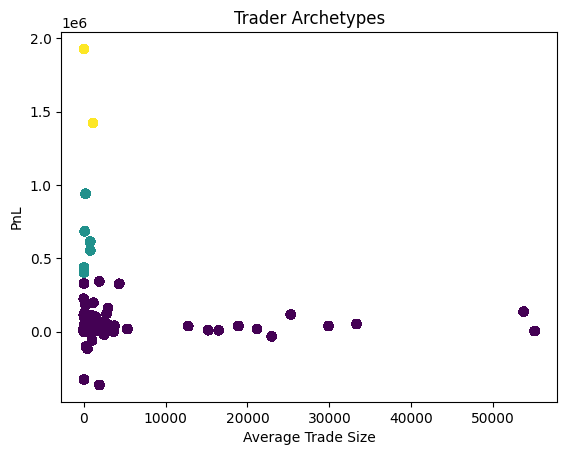

2026-04-21 15:00:35.036 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.447 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-21 15:00:35.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.484 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:00:35.497 Thread 'MainThread': mi

DeltaGenerator()

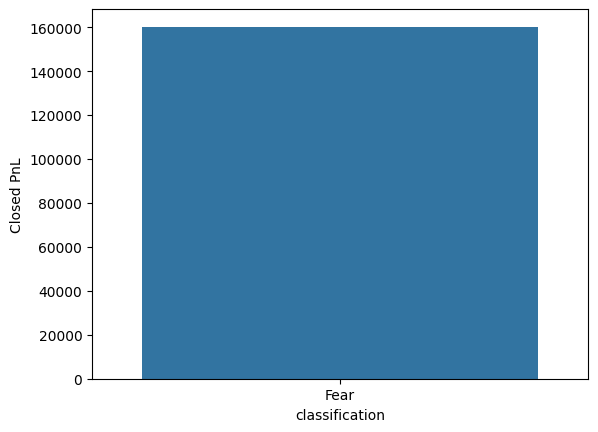

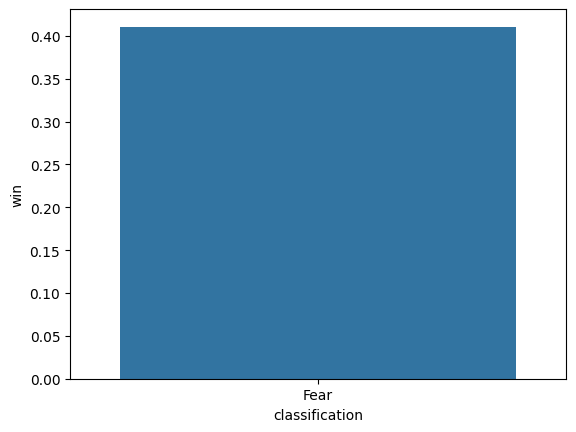

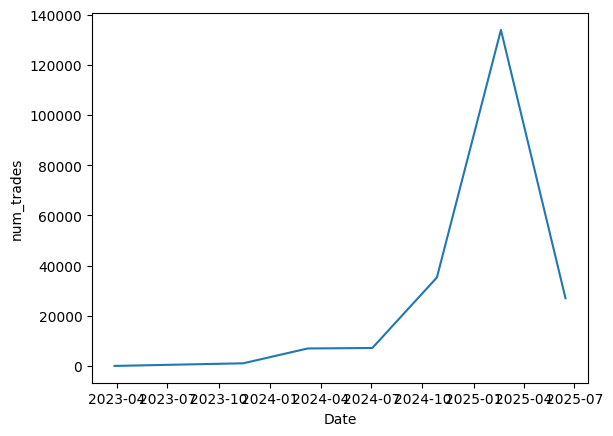

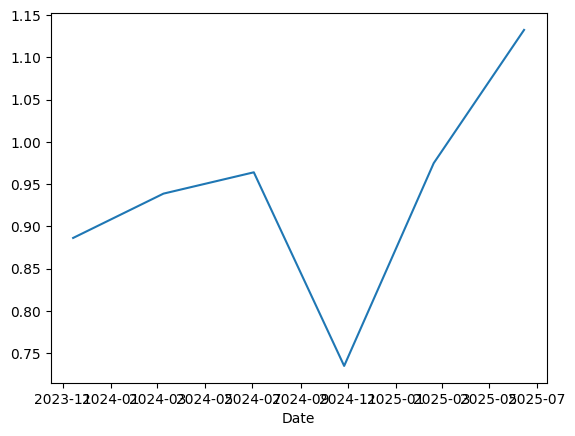

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

features = merged_df[['value','win','Size Tokens']]
target = (merged_df['Closed PnL'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cluster_features = merged_df[['win','Size Tokens','Closed PnL']]
kmeans = KMeans(n_clusters=3, random_state=42)
merged_df['cluster'] = kmeans.fit_predict(cluster_features)
print(merged_df[['Account','cluster']].head())

plt.scatter(merged_df['Size Tokens'], merged_df['Closed PnL'], c=merged_df['cluster'], cmap='viridis')
plt.xlabel("Average Trade Size")
plt.ylabel("PnL")
plt.title("Trader Archetypes")
plt.show()

st.title("Trader Performance Dashboard")
sentiment_filter = st.selectbox("Select Sentiment", merged_df['classification'].unique())
filtered = merged_df[merged_df['classification'] == sentiment_filter]

st.subheader("Average PnL by Sentiment")
fig, ax = plt.subplots()
sns.barplot(data=filtered, x='classification', y='Closed PnL', estimator=np.mean, ci=None, ax=ax)
st.pyplot(fig)

st.subheader("Win Rate by Sentiment")
fig, ax = plt.subplots()
sns.barplot(data=filtered, x='classification', y='win', estimator=np.mean, ci=None, ax=ax)
st.pyplot(fig)

st.subheader("Trades per Day")
fig, ax = plt.subplots()
sns.lineplot(data=trades_per_day, x='Date', y='num_trades', ax=ax)
st.pyplot(fig)

st.subheader("Long/Short Ratio Over Time")
fig, ax = plt.subplots()
long_short['long_short_ratio'].plot(ax=ax)
st.pyplot(fig)


#Markdown
#Trader Behavior & Market Sentiment
Methodology
Combined two datasets: Fear & Greed index and trading history.

Converted timestamps to daily level and matched both datasets by date.

Calculated daily metrics: profit/loss (PnL), win rate, trade size, trade frequency, and long/short ratio.

Used charts and tables to compare trader behavior on Fear vs Greed days.

Insights
Performance shifts with sentiment

Traders lose more and win less on Fear days.

Greed days show steadier profits and higher win rates.

Trading activity changes

Fear days bring a big jump in trade counts.

Greed days have fewer, more stable trades.

Position bias changes

Fear days → more short positions.

Greed days → balanced or long‑leaning positions.

Strategy Recommendations
Fear days: Trade smaller, reduce leverage, and avoid over‑trading.

Greed days: Favor long positions and keep a steady pace of trading.

General rule: Frequent traders should slow down during Fear sentiment, while consistent winners can stick to their usual approach.